<h1>Chapter 7-Logistic Regression</h1>

<p>We apply logistic regression to study whether individuals develop diabetes. The dependent variable is:</p>

<p>•	y = 1: has diabetes<br />
•	y = 0: does not have diabetes</p>

<p>The explanatory variables include:</p>

<p>•	Pregnant – number of pregnancies<br />
•	Insulin – insulin level<br />
•	BMI – body mass index<br />
•	Age – age of the individual<br />
•	Glucose – blood glucose level<br />
•	BP – blood pressure<br />
•	Pedigree – genetic predisposition</p>


First five observations:
   pregnant  glucose  bp  skin  insulin   bmi  pedigree  age  outcome
0         6      148  72    35        0  33.6     0.627   50        1
1         1       85  66    29        0  26.6     0.351   31        0
2         8      183  64     0        0  23.3     0.672   32        1
3         1       89  66    23       94  28.1     0.167   21        0
4         0      137  40    35      168  43.1     2.288   33        1

Confusion Matrix:
[[115  10]
 [ 25  42]]


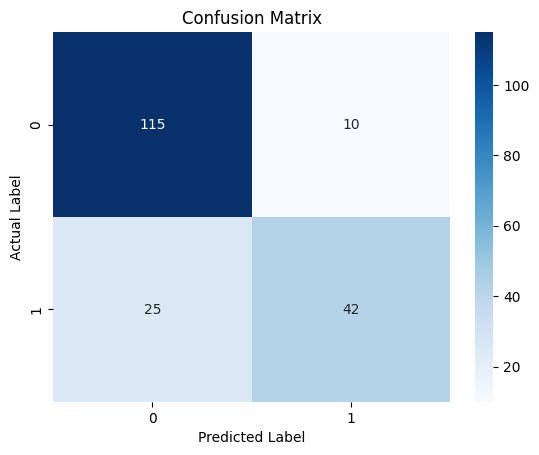


Classification Report:
                  precision    recall  f1-score   support

Without Diabetes       0.82      0.92      0.87       125
   With Diabetes       0.81      0.63      0.71        67

        accuracy                           0.82       192
       macro avg       0.81      0.77      0.79       192
    weighted avg       0.82      0.82      0.81       192

Optimization terminated successfully.
         Current function value: 0.490919
         Iterations 6

Logit Model Summary:
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                  576
Model:                          Logit   Df Residuals:                      568
Method:                           MLE   Df Model:                            7
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                  0.2410
Time:                        10:57:11   Log-Likelihood:                -282.77
converged:                 

In [1]:
# ============================================
# Logistic Regression Example: Diabetes Dataset
# ============================================

# --------------------------------------------
# Step 1: Import required libraries
# --------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report

import statsmodels.api as sm

# --------------------------------------------
# Step 2: Load and clean the dataset
# --------------------------------------------

# Load dataset
df = pd.read_excel('Chapter_07-diabetes.xlsx')

# Convert all columns to numeric (important for modeling)
df = df.apply(pd.to_numeric)

# Preview data
print("First five observations:")
print(df.head())

# --------------------------------------------
# Step 3: Define features (X) and target (y)
# --------------------------------------------
feature_cols = [
    'pregnant', 'insulin', 'bmi',
    'age', 'glucose', 'bp', 'pedigree'
]

X = df[feature_cols]   # Independent variables
y = df['outcome']      # Dependent variable

# --------------------------------------------
# Step 4: Split into training and testing sets
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=16
)

# --------------------------------------------
# Step 5: Estimate logistic regression (sklearn)
# --------------------------------------------
model = LogisticRegression(max_iter=1000)

# Fit the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# --------------------------------------------
# Step 6: Evaluate model performance
# --------------------------------------------
# Confusion matrix
conf_matrix = metrics.confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(conf_matrix)

# --------------------------------------------
# Step 7: Visualize confusion matrix
# --------------------------------------------
plt.figure()
sns.heatmap(
    pd.DataFrame(conf_matrix),
    annot=True,
    fmt='g',
    cmap = 'Blues'
)

plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# --------------------------------------------
# Step 8: Classification report
# --------------------------------------------
target_names = ['Without Diabetes', 'With Diabetes']

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# --------------------------------------------
# Step 9: Estimate Logit model (statsmodels)
# --------------------------------------------
# Add constant for intercept
X_train_sm = sm.add_constant(X_train)

# Fit Logit model
logit_model = sm.Logit(
    y_train.astype(float),
    X_train_sm.astype(float)
).fit()

# Display results
print("\nLogit Model Summary:")
print(logit_model.summary())
